In [11]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

In [12]:
cifar10 = tf.keras.datasets.cifar10  # Import CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [13]:
for i in [x_train, y_train, x_test, y_test]:
    print(i.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


Label: [6]


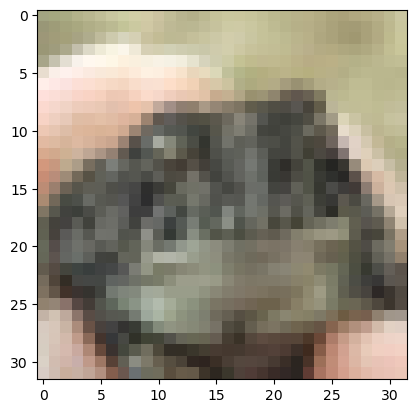

In [14]:
plt.imshow(x_train[25])
print("Label:", y_train[25])
plt.show()

In [19]:
x_train = x_train / 255.0
x_test = x_test / 255.0
print(x_train.shape, x_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


In [21]:
num_classes = 10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [23]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)
print(y_train.shape, y_test.shape)

(50000, 10) (10000, 10)


In [25]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

C:\Users\vinod\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train, y_train,
    batch_size=30,
    epochs=10,
    validation_data=(x_test, y_test),
    shuffle=True
)

Epoch 1/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - accuracy: 0.1961 - loss: 2.1581 - val_accuracy: 0.3543 - val_loss: 1.7766
Epoch 2/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.3767 - loss: 1.7257 - val_accuracy: 0.4431 - val_loss: 1.5310
Epoch 3/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.4647 - loss: 1.4904 - val_accuracy: 0.5116 - val_loss: 1.3760
Epoch 4/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.5196 - loss: 1.3566 - val_accuracy: 0.5258 - val_loss: 1.3401
Epoch 5/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.5478 - loss: 1.2814 - val_accuracy: 0.5739 - val_loss: 1.2294
Epoch 6/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 36s 22ms/step - accuracy: 0.5741 - loss: 1.2023 - val_accuracy: 0.5805 - val_loss: 1.1882
Epoch 7/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.5976 - loss: 1.1411 - val_accuracy: 0.5668 - val_loss: 1.2407
Epoch 8/10
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.6177 -

In [ ]:
plt.figure(figsize=[15, 6])

In [ ]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy', size=20)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss', size=20)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [ ]:
plt.show()

In [ ]:
predictions = model.predict(x_test)
index = random.randint(0, len(x_test) - 1)

In [ ]:
plt.imshow(x_test[index])
plt.title(f"Predicted: {class_names[np.argmax(predictions[index])]}, Actual: {class_names[np.argmax(y_test[index])]}")
plt.show()